













































# Lab 2: Logistic regression - Titanic

https://www.kaggle.com/c/titanic/data

In [391]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [392]:
import sklearn as sk

In [393]:
filename = 'titanic'

from urllib.request import urlretrieve
urlretrieve("https://bianchi.wp.imt.fr/files/2023/12/titanic.zip", filename + '.zip')

import os
zip_file = os.path.join(os.getcwd(), 'titanic.zip')

import zipfile
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(os.getcwd())

In [394]:
df = pd.read_csv("traintitanic.csv")

In [395]:
# Using head(), info(), describe() etc. inspect the dataset. Which features are numerical, which ones are categorical? Comment about missing data.
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


 Which features are numerical, which ones are categorical? Comment about missing data.
 PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare are numerical.
 Name, Sex, Ticket are categorical.

For the missing data:
Age: This column has 714 non-null values out of 891, meaning 177 missing values.
Cabin: This column has only 204 non-null values out of 891, meaning 687 missing values. This is a significant proportion.
Embarked: This column has 889 non-null values, meaning 2 missing values

In [396]:
# Using the df.groupby("Pclass"), comment about the nature of the passengers as a function of the class ticket (first, second or third class)
df.groupby("Pclass").mean(numeric_only=True)

,PassengerId,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,,
1,461.597222,0.629630,38.233441,0.416667,0.356481,84.154687
2,445.956522,0.472826,29.877630,0.402174,0.380435,20.662183
3,439.154786,0.242363,25.140620,0.615071,0.393075,13.675550


As the class ticket increases from 1 to 3, the passengers tend to have higher chance of survival, to be older, to have a bigger family size and spend less on the fare.  

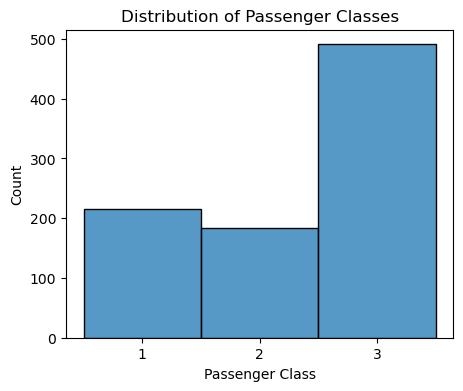

In [397]:
# Plot the histogram of Passenger's classes
plt.figure(figsize=(5,4))
sns.histplot(df["Pclass"], discrete=True, kde=False)
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.title("Distribution of Passenger Classes")
plt.xticks([1, 2, 3])
plt.show()

In [398]:
# Comment about the impact of the sex of passengers
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Female passengers have higher survival rate than male. 

In [399]:
# Comment about the impact of the embarkation city. How do you explain the discrepancies in survival rate?
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [400]:
df.groupby(["Pclass","Embarked","Sex"])["Survived"].count()

Pclass  Embarked  Sex   
1       C         female     43
                  male       42
        Q         female      1
                  male        1
        S         female     48
                  male       79
2       C         female      7
                  male       10
        Q         female      2
                  male        1
        S         female     67
                  male       97
3       C         female     23
                  male       43
        Q         female     33
                  male       39
        S         female     88
                  male      265
Name: Survived, dtype: int64

Passengers from Cherbourg have the highest survival rate at 55.36%, compared to Queenstown at 38.96% and Southampton at 33.70%. This is the proportion of passengers in First Class is the highest for those from Cherbourg and passengers in First Class generally have higher chance of survival. In addition, more than of passengers from Cherbourg in First Class are females (highest proportion of females in First Class), this also accounts for the highest survival rate for Cherbourg.

([<matplotlib.axis.XTick at 0x140a7cfe0>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

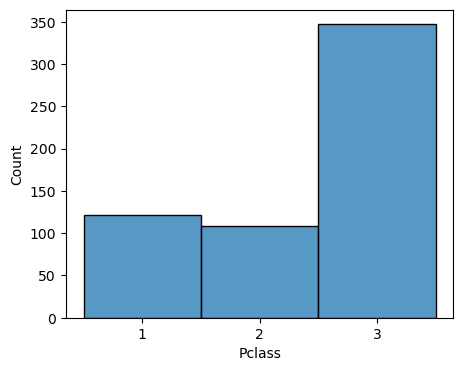

In [401]:
#Plot the histogram of the number of men in each class. Do the same for women. Comment.
plt.figure(figsize=(5,4))
sns.histplot(df[df["Sex"] == "male"]["Pclass"], bins=3, discrete=True, label="Men")
plt.xticks([1, 2, 3])

([<matplotlib.axis.XTick at 0x14006cb60>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

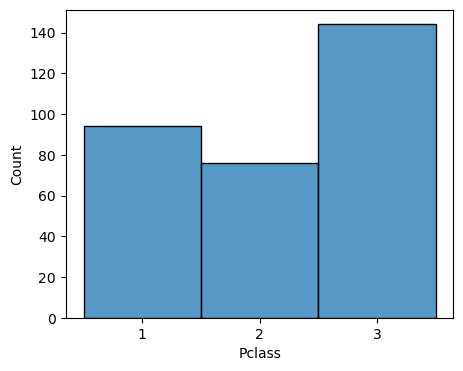

In [402]:
plt.figure(figsize=(5,4))
sns.histplot(df[df["Sex"] == "female"]["Pclass"], bins=3, discrete=True, label="Women")
plt.xticks([1, 2, 3])

<Figure size 1000x1000 with 0 Axes>

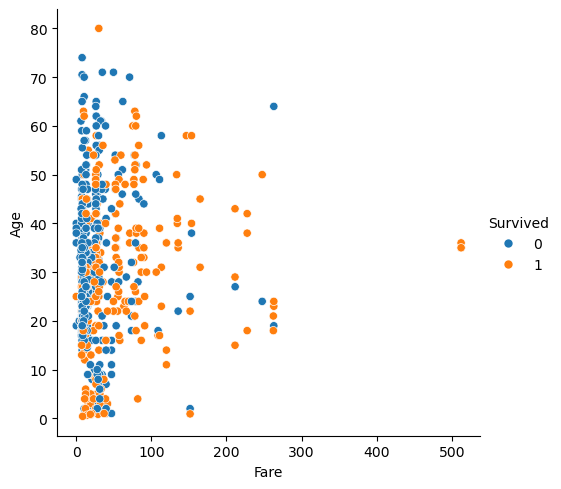

In [403]:
# Comment briefly the following code
plt.figure(figsize=(10,10))
sns.relplot(data=df, x="Fare", y="Age", hue="Survived")

Answer: The plot shows how fare and age impact the chance of survival. We can tell that the blue dots (those who died) mainly distributed at fare = 0, age around 40. As Fare increases, the chance of survival also increases. For age < 10, the survival rate is high. 

In [404]:
# In case you believe that other plots are interesting to vizualize the data set, you can provide them here.

# Categorical encoding

Certain columns (sex, embarked, etc.) are categorical. We need to transform them into numerical features.

In [405]:
# Create a new column "Sex_num" where the strings "male" and "female" are replaced by a binary integer.
df["Sex_num"] = (df["Sex"]=="male").astype("int") #That's ok because there is no missing data in the "Sex" column

In [406]:
# What is the following code doing?
pd.get_dummies(df['Embarked'])

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


This code converts the categorical text data into a boolean value, later 

In [407]:
# Using pd.get_dummies, create new columns in the dataframe df, one for each embarkation port
ports = pd.get_dummies(df['Embarked'])
df["C"] = (df["Embarked"]=="C").astype("int")
df["Q"] = (df["Embarked"]=="Q").astype("int")
df["S"] = (df["Embarked"]=="S").astype("int")

In [408]:
# We may drop the two columns "Sex" and "Embarked", as we now included their onehot counterparts in the dataframe. Check that the following code drops theses columns
df.drop(columns=["Sex","Embarked"],inplace=True)

In [409]:
# Use df.head(). Did the dropped column disappear? Solve possible issued using the argument inplace=True, in the drop method
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_num,C,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,0,0,1


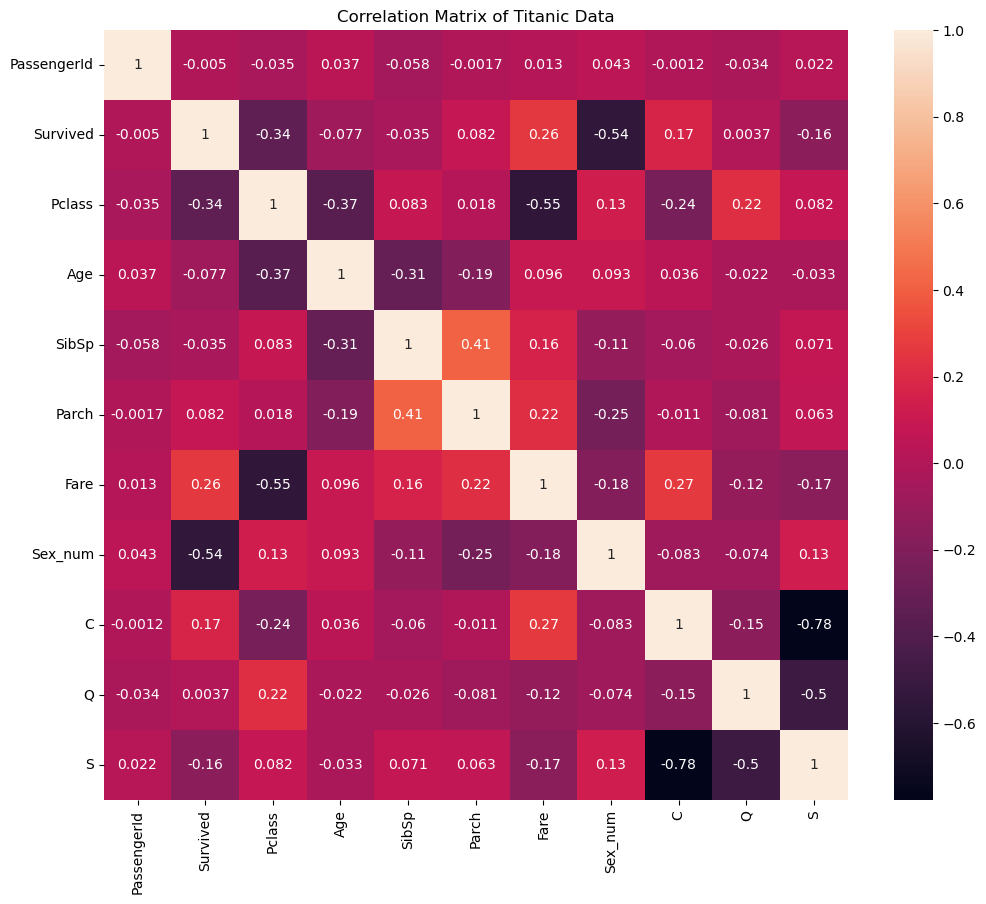

In [410]:
# What does the matrix df.corr() represent? Provide your interpretation of the numbers you see.
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix of Titanic Data")
plt.show()

matrix df.corr() represent the linear relationship between two variables. Higher the absolute value means that two variables are more linearly related. 
With respect to rate of survival, we can see that it has a strong negative correlation with Sex_num (-0.54), a moderate negative correlation with Pclass (-0.34) and a moderate positive correlation with Fare (0.26)

# Data cleansing
Check the number of missing values in "Age". You can either


*   Do nothing (the rows with missing "Age" will be ignored in the training stage)
*   Or fill the missing values with some value of your choice.


Do something smart.



In [411]:
# Do something smart to handle the problem of missing values in the "Age" column
df["Age"] = df["Age"].fillna(df.groupby(["Pclass", "Sex_num"])["Age"].transform("median"))

In [412]:
# We will train a logistic regression. Write below the columns which you would like to keep as features for logistic regression.
# n.b.: We will NOT keep the columns Ticket and Cabin. Why?
mycolumns = ["Pclass", "Sex_num", "Fare", "Age", "C", "S", "Q", "Parch"]

Answer: 
Ticket contains unique values which can make analysis difficult. 
Cabin has too many missing values. 

#Logistic regression


In [413]:
# Train a logistic regression classifier using sklearn, based on the above dataframe and the chosen columns.
# Explain the meaning of the parameter in the logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)

penalty = l2 : l2 is a type of regularization where we consider the sqaure loss.
C = 1.0 refers to the strength of the regularization
max_iter = 1000 means the maximum number of iterations taken for the solvers to converge.

In [414]:
# Fit the model
X = df[mycolumns]
y = df["Survived"]
lr.fit(X,y)

LogisticRegression(max_iter=1000)

In [415]:
# Display the coefficients of the logistic regression. Discuss the possible positive/negative impact on survival of certain parameters

coefficients = pd.DataFrame({
    "Feature": mycolumns,
    "Coefficient": lr.coef_[0]
})

print(coefficients)

   Feature  Coefficient
0   Pclass    -1.179940
1  Sex_num    -2.536858
2     Fare     0.000708
3      Age    -0.037591
4        C     0.115694
5        S    -0.342671
6        Q    -0.012128
7    Parch    -0.190460


From the coefficient, we can conclude C (embarkation port being Cherbourg) has a positive impact on survival rate and Pclass, Sex_num have a negative impact on survival rate.

# Performance evaluation


In [416]:
# Load the test data
Xtest = pd.read_csv("testtitanic.csv")
ytest = pd.read_csv("gender_submission.csv")
dftest = pd.merge(Xtest,ytest)

In [417]:
# Process the test features in order to obtain the same format as for the train set
dftest["Sex_num"] = (dftest["Sex"]=="male").astype("int")

dftest["Age"] = dftest["Age"].fillna(dftest.groupby(["Pclass", "Sex_num"])["Age"].transform("median"))

ports = pd.get_dummies(dftest['Embarked'])
dftest["C"] = (dftest["Embarked"]=="C").astype("int")
dftest["Q"] = (dftest["Embarked"]=="Q").astype("int")
dftest["S"] = (dftest["Embarked"]=="S").astype("int")

dftest.drop(columns=["Sex","Embarked"],inplace=True)

In [418]:
# Define a dataframe with only the columns you want to keep (and the label)
dftest = dftest[mycolumns+["Survived"]]
dftest.head()

,Pclass,Sex_num,Fare,Age,C,S,Q,Parch,Survived
0,3,1,7.8292,34.5,0,0,1,0,0
1,3,0,7.0000,47.0,0,1,0,0,1
2,2,1,9.6875,62.0,0,0,1,0,0
3,3,1,8.6625,27.0,0,1,0,0,0
4,3,0,12.2875,22.0,0,1,0,1,1


In [419]:
# Check if there are some missing values. If needed, row containing missing values can be dropped using the dropna() method (inplace)
dftest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex_num   418 non-null    int64  
 2   Fare      417 non-null    float64
 3   Age       418 non-null    float64
 4   C         418 non-null    int64  
 5   S         418 non-null    int64  
 6   Q         418 non-null    int64  
 7   Parch     418 non-null    int64  
 8   Survived  418 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 29.5 KB


In [420]:
dftest.dropna(inplace=True)
dftest.info() #check

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    417 non-null    int64  
 1   Sex_num   417 non-null    int64  
 2   Fare      417 non-null    float64
 3   Age       417 non-null    float64
 4   C         417 non-null    int64  
 5   S         417 non-null    int64  
 6   Q         417 non-null    int64  
 7   Parch     417 non-null    int64  
 8   Survived  417 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 32.6 KB


In [421]:
#lr.fit(df[mycolumns], df["Survived"])

In [428]:
# Compute the hard predictions on the test set (using only the columns to keep)
X_htest = dftest[mycolumns]
y_hardpred = lr.predict(X_htest)

print(y_hardpred)

   Pclass  Sex_num     Fare   Age  C  S  Q  Parch
0       3        1   7.8292  34.5  0  0  1      0
1       3        0   7.0000  47.0  0  1  0      0
2       2        1   9.6875  62.0  0  0  1      0
3       3        1   8.6625  27.0  0  1  0      0
4       3        0  12.2875  22.0  0  1  0      1
[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 0
 1 0 1 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0 1
 0 1 1 0 1 0 0 0 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1 0
 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 1
 0 0 0 0 0 0 0 0 0 1 0 1 

In [423]:
# Compute the accuracy score
from sklearn.metrics import accuracy_score
y_htest = dftest["Survived"]

accuracy = accuracy_score(y_htest, y_hardpred)

print(f"The accuracy score is {accuracy:.8f}")

The accuracy score is 0.93764988


In [427]:
# Compute the soft predictions unsing predict_proba
X_stest = dftest[mycolumns]
y_softpred = lr.predict_proba(X_stest)

Text(0.5, 1.0, 'ROC Curve Using Soft Predictions')

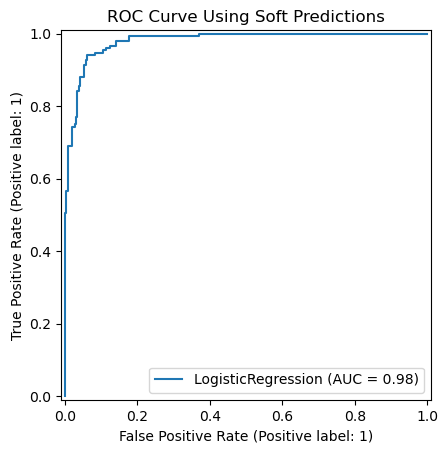

In [425]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(lr, dftest[mycolumns], dftest["Survived"])
plt.title("ROC Curve Using Soft Predictions")

# Bonus question: do whatever you find useful

Here are some examples:

*   Try to include useful elements of the Cabin number
*   Try different regularization parameters
* Try L1 regularization instead of ridge
* Try linear regression





In [430]:
#Try linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linear = LinearRegression() 
linear.fit(df[mycolumns], df['Survived'])
linear_pred = linear.predict(dftest[mycolumns])
mse = mean_squared_error(dftest['Survived'], linear_pred)
print(mse)

0.07426291660087403
